# TIE — El efecto de las billeteras digitales en el acceso al crédito
## Pipeline de construcción de datos y estimación — VERSIÓN CORREGIDA

Reconstruye el pipeline de `Untitled2.ipynb` con las correcciones de la revisión de código integradas en el punto donde se originan, no como parches al final. Sigue la numeración del capítulo metodológico.

**Correcciones integradas (de la revisión de código):**

| # | Problema | Qué cambia |
|---|---|---|
| 1 | `Ocupado` usaba `.notna()` sobre texto; `' '` (no ocupado) no se detecta como vacío | Se convierte a numérico antes de evaluar |
| 2 | El panel se construía por cruce ingenuo de llaves (27.25%); el texto narra `PANEL==1` (65.85%) pero nunca se usaba | Se usa `PANEL==1` como filtro real |
| 3 | `sin_sunat` se aplicaba a todos los `P507`, no solo a independientes/empleadores | Se agrega el filtro `P507==2` |
| 4 | `CreditoInformal_2025` usa `P558G7` en el código pero la Tabla A documenta `P558E1_3` | Confirmado con el Diccionario de Datos 2025: `P558G7` es correcta, `P558E1_3` es "Cuenta corriente" (la cita de Tabla A está mal) |

**Un quinto hallazgo, fuera de la revisión que me pasaste:** el modelo principal (H1/H2) calculaba el efecto de la interacción con `get_margeff(at='overall')`, tratando la columna `Billetera×Informal` como regresor independiente. En un probit eso no es el efecto marginal de la interacción — es justo lo que Ai & Norton (2003), ya citado en tu capítulo, advierten evitar. Se reemplaza por la derivada cruzada por subgrupo con errores estándar por método delta (detalle con números reales en 2.6.1).

**Un sexto hallazgo, encontrado con el Diccionario de Datos 2025:** la variable de gasto del hogar existe en la Sumaria pero se llama `GASHOG2D`/`GASHOG1D` (con sufijo "D") — el pipeline original la buscaba sin ese sufijo y nunca la encontraba. Ya corregido y extraíble (Sección 2.3.6, opcional — no afecta ningún resultado ya reportado).

**Qué se validó con datos reales y qué queda pendiente:**
- ✅ Validado end-to-end contra `MASTER_2024.csv`/`MASTER_2025.csv` reales, hasta el modelo H1/H2 (Secciones 2.2–2.6.3). Los números de esas secciones (N, tasas, coeficientes, Tabla D) son reales.
- ✅ Definiciones de variable (`P507`, `P510A1`, `P511A`, `P558G7`, `P558E1_3`, `GASHOG2D`/`GASHOG1D`) confirmadas contra el Diccionario de Datos 2025 oficial del INEI.
- ⚠️ `CreditoInformal_2025` y `Gasto_per_capita` (2.3.5, 2.3.6, H3, 2.6.4–2.6.5): el código corre sin errores — lo probé con módulos crudos sintéticos para confirmar que la lógica y el cruce de llaves funcionan — pero **los números que producen con tus datos reales son enteramente distintos**, porque ninguna de esas variables está en los 4 archivos que subiste originalmente, solo en los módulos crudos de 2025. Vas a ver salir números la primera vez que corras esas celdas en tu máquina; son los reales, no los que yo vi con datos sintéticos.
- ⚠️ Las rutas (`base = ...`) siguen apuntando a carpetas locales de Windows — ajústalas si cambiaron.

## 0. Configuración
Una sola vez, al inicio — el resto del notebook reutiliza `base`. Ajusta esta ruta a donde tengas los módulos del INEI y donde quieras guardar los archivos intermedios.

In [1]:
import pandas as pd
import numpy as np
import os
import json
import statsmodels.api as sm
from scipy import stats

pd.set_option('display.width', 120)

# ============================================================
# RUTA BASE — AJUSTAR SI ES NECESARIO
# ============================================================
base = r"C:\Users\Dafne\Downloads\Base Datos"

## 2.2.1. Extracción de módulos INEI y construcción de variables (CORREGIDO)

`reparar_variables()` es la única función que construye `Ocupado`, `Informal`, `CreditoFormal`, `Billetera` y `CreditoInformal`. Se usa tanto al construir `MASTER_2024`/`MASTER_2025` desde cero como para reparar un `MASTER_*.csv` que ya existe — así el fix vive en un solo lugar y no puede quedar aplicado en una celda sí y en otra no (que es exactamente lo que pasó con el bug de `Ocupado`: se corrigió en la comparabilidad de la Tabla A pero no en el origen).

**Fix 1 (Ocupado):** `P507` trae `' '` (espacio) para "no ocupado" en vez de `NaN` real. `.notna()` sobre el string no lo detecta; convertir a numérico primero sí.

**Fix 3 (sin_sunat):** la pregunta de registro en SUNAT (`P510A1`) la responden también dependientes, TFNR y la categoría 7 sin documentar — no solo independientes/empleadores. El criterio de la Sección 2.3.4 es explícito: la regla de SUNAT aplica *solo* a `P507==2`.

**Fix 4 (CreditoInformal):** se extrae `P558G7` (la variable que el código realmente usa) y, adicionalmente, `P558E1_3` (la que documenta la Tabla A), para poder comparar ambas. **Pendiente de tu lado:** confirmar en la ficha técnica el universo de `P558G7` (¿se pregunta a todos, o solo a quienes ya declararon algún préstamo?) — normativa [P1] de la Sección 2.2.1.

In [2]:
def encontrar_archivo(carpeta, inicio_nombre):
    for f in os.listdir(carpeta):
        if f.upper().replace(".CSV", "").startswith(inicio_nombre.upper()):
            return os.path.join(carpeta, f)
    raise FileNotFoundError(f"No se encontró {inicio_nombre} en {carpeta}")


def leer_csv_inei(ruta):
    for sep in [",", ";"]:
        for enc in ["utf-8-sig", "latin1"]:
            try:
                df = pd.read_csv(ruta, sep=sep, encoding=enc, low_memory=False, dtype=str)
                if len(df.columns) > 1:
                    df.columns = df.columns.str.strip()
                    return df
            except Exception:
                pass
    raise ValueError(f"No se pudo leer el archivo: {ruta}")


def to_num(serie):
    return pd.to_numeric(serie, errors="coerce")


def construir_llave_persona(df, llaves=None, nombre="llave_persona"):
    '''
    Agrega una columna de llave (por defecto 'llave_persona':
    CONGLOME-VIVIENDA-HOGAR-CODPERSO; pasar llaves=["CONGLOME","VIVIENDA","HOGAR"]
    y nombre="llave_hogar" para el nivel hogar, ej. la Sumaria), normalizando
    cada componente por la via numerica (pd.to_numeric -> Int64 -> str). Esto
    es importante: segun si un CSV se leyo con dtype=str (preserva ceros a
    la izquierda, ej. '015009') o sin especificar dtype (pandas infiere
    numerico y los elimina, ej. '15009'), la misma persona/hogar puede
    terminar con dos llaves de texto distintas. Pasar siempre por numerico
    antes de volver a texto asegura que la MISMA persona/hogar tenga
    SIEMPRE la MISMA llave sin importar como se leyo el archivo de origen.
    Es la UNICA funcion que debe usarse para esto en todo el notebook.
    '''
    if llaves is None:
        llaves = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
    df = df.copy()
    for c in llaves:
        df[f"_{c}_k"] = pd.to_numeric(df[c], errors="coerce").astype("Int64").astype(str)
    df[nombre] = df[[f"_{c}_k" for c in llaves]].agg("-".join, axis=1)
    return df.drop(columns=[f"_{c}_k" for c in llaves])


def reparar_variables(df):
    '''
    Construye/corrige, a partir de las columnas crudas del INEI ya presentes
    en df, las variables: Ocupado, Informal, CreditoFormal, Billetera,
    CreditoInformal (si P558G7 esta disponible), y las _num auxiliares.

    Es la UNICA funcion que debe usarse para esto en todo el notebook --
    tanto al construir MASTER_*.csv desde los modulos crudos, como para
    reparar un MASTER_*.csv que ya fue generado con el pipeline anterior.
    '''
    df = df.copy()

    df["Edad"] = to_num(df["P208A"]) if "P208A" in df.columns else df.get("Edad")
    df["P507_num"] = to_num(df["P507"])
    df["P510A1_num"] = to_num(df["P510A1"])
    df["P511A_num"] = to_num(df["P511A"])

    # --- FIX 1: Ocupado. Antes: df["P507"].notna() marcaba ' ' como ocupado ---
    df["Ocupado"] = df["P507_num"].notna().astype(int)

    # --- FIX 3: sin_sunat restringido a independientes/empleadores (P507==2) ---
    tfnr = df["P507_num"] == 5
    trab_hogar = df["P507_num"] == 6
    sin_sunat = (df["P507_num"] == 2) & (df["P510A1_num"] == 3)
    dependiente = df["P507_num"].isin([3, 4])
    sin_contrato = df["P511A_num"] == 7

    df["Informal"] = (
        sin_sunat.fillna(False)
        | tfnr.fillna(False)
        | trab_hogar.fillna(False)
        | (dependiente & sin_contrato.fillna(False))
    ).astype(int)
    df.loc[df["Ocupado"] == 0, "Informal"] = pd.NA

    # --- Billetera / CreditoFormal: confirmadas correctas por la revisión, sin cambios ---
    df["P558E1_4"] = to_num(df.get("P558E1_4")).fillna(0)
    df["P558E1_9"] = to_num(df.get("P558E1_9")).fillna(0)
    df["P558E1_8"] = to_num(df.get("P558E1_8")).fillna(0)
    df["CreditoFormal"] = ((df["P558E1_4"] == 4) | (df["P558E1_9"] == 9)).astype(int)
    df["Billetera"] = (df["P558E1_8"] == 8).astype(int)

    # --- FIX 4: CreditoInformal — variable de modelo (P558G7) + variable documentada en Tabla A (P558E1_3) ---
    if "P558G7" in df.columns:
        df["CreditoInformal"] = (to_num(df["P558G7"]).fillna(0) == 7).astype(int)
    if "P558E1_3" in df.columns:
        df["CreditoInformal_P558E1_3"] = (to_num(df["P558E1_3"]).fillna(0) == 3).astype(int)

    # Gasto per cápita, si está disponible (ver nota más abajo)
    if "GASHOG2" in df.columns and "MIEPERHO" in df.columns:
        df["Gasto_per_capita"] = to_num(df["GASHOG2"]) / to_num(df["MIEPERHO"])

    return df

**Nota aparte, no pedida en la revisión, cerrada con el Diccionario de Datos 2025:** ni `MASTER_2024.csv` ni `MASTER_2025.csv` traen `GASHOG2`/`GASHOG1` — el merge de la Sumaria nunca encontró esa columna con esos nombres exactos, así que `Gasto_per_capita` nunca se llegó a construir (no aparece en ninguna regresión ya corrida; Tabla D no tiene fila de gasto per cápita, coherente con esto). **El Diccionario de Datos 2025 (Sumaria, Archivo `Sumaria-2025-12g`/`Sumaria-2025-8g`) confirma que la variable existe, pero se llama `GASHOG2D` (Gasto Total bruto) y `GASHOG1D` (Gasto monetario) — con sufijo "D"**, no `GASHOG2`/`GASHOG1`. `construir_master()` ya busca ambos nombres (con y sin sufijo) y renombra a `GASHOG2` internamente, así que si reconstruyes desde los módulos crudos esto ya sale resuelto. Para tu `BASE_REGRESIONES.csv` ya existente (que no pasó por esa función), la celda de la Sección 2.3.6 más abajo lo extrae directo de la Sumaria cruda, igual que se hizo con `CreditoInformal_2025` en 2.3.5.

In [3]:
def construir_master(anio, carpetas):
    '''
    carpetas: dict como
        {"Mod100": (ruta_carpeta, "Enaho01-2024-100"), "Mod200": (...), ...,
         "Mod500": (...), "Sumaria": (...)}
    Extrae, junta y construye las variables (con los fixes) para un anio.
    '''
    print(f"Cargando módulos {anio} y extrayendo variables...")

    ruta_200 = encontrar_archivo(*carpetas["Mod200"])
    df200 = leer_csv_inei(ruta_200)[["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO", "P203", "P207", "P208A"]]

    ruta_300 = encontrar_archivo(*carpetas["Mod300"])
    df300 = leer_csv_inei(ruta_300)[["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO", "P301A", "P301B"]]

    ruta_500 = encontrar_archivo(*carpetas["Mod500"])
    df500_full = leer_csv_inei(ruta_500)
    # P558E1_3 (doc. Tabla A) y P558G7 (variable de modelo real, FIX 4) se
    # extraen ambas si existen, ademas de las columnas ya usadas.
    cols_500 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO",
                "P507", "P510A1", "P511A", "P512A",
                "P558E1_4", "P558E1_8", "P558E1_9"]
    for extra in ["P558E1_3", "P558G7"]:
        if extra in df500_full.columns:
            cols_500.append(extra)
        else:
            print(f"  aviso: {extra} no encontrada en el módulo 500 de {anio}")
    df500 = df500_full[cols_500]

    ruta_100 = encontrar_archivo(*carpetas["Mod100"])
    df100 = leer_csv_inei(ruta_100)
    cols_100 = ["CONGLOME", "VIVIENDA", "HOGAR", "DOMINIO", "ESTRATO", "PANEL"]
    for fac in ["FACTOR", "FACPOB", "FACTOR07"]:
        if fac in df100.columns:
            cols_100.append(fac)
            break
    df100 = df100[cols_100]

    ruta_sum = encontrar_archivo(*carpetas["Sumaria"])
    df_sum = leer_csv_inei(ruta_sum)
    cols_sum = ["CONGLOME", "VIVIENDA", "HOGAR"]
    # CONFIRMADO en el Diccionario de Datos 2025: la variable se llama
    # GASHOG2D / GASHOG1D (con sufijo "D"), no GASHOG2/GASHOG1 como se
    # buscaba antes -- por eso nunca se encontraba. Se deja el nombre sin
    # sufijo como respaldo por si un año distinto no lo trae.
    gasto_encontrada = None
    for g in ["GASHOG2D", "GASHOG1D", "GASHOG2", "GASHOG1"]:
        if g in df_sum.columns:
            gasto_encontrada = g
            break
    if gasto_encontrada:
        df_sum = df_sum.rename(columns={gasto_encontrada: "GASHOG2"})
        cols_sum.append("GASHOG2")
        print(f"  Gasto del hogar encontrado como '{gasto_encontrada}' -> renombrado a 'GASHOG2'")
    else:
        print(f"  aviso: no se encontró ninguna variable de gasto del hogar en la Sumaria {anio} -- Gasto_per_capita no se podrá construir")
    for m in ["MIEPERHO", "MIEMBRO"]:
        if m in df_sum.columns:
            cols_sum.append(m)
            break
    df_sum = df_sum[cols_sum]

    print("Extracción lista. Uniendo bases...")
    llave_persona = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
    llave_hogar = ["CONGLOME", "VIVIENDA", "HOGAR"]

    df = df200.merge(df300, on=llave_persona, how="left")
    df = df.merge(df500, on=llave_persona, how="left")
    df = df.merge(df100, on=llave_hogar, how="left")
    df = df.merge(df_sum, on=llave_hogar, how="left")

    df = construir_llave_persona(df)

    print("Construyendo variables de investigación (con fixes 1, 3 y 4 integrados)...")
    df = reparar_variables(df)

    n_total = len(df)
    print(f"\nDIAGNÓSTICO {anio}: total={n_total:,} | ocupados (corregido)={df['Ocupado'].sum():,} "
          f"({df['Ocupado'].mean():.1%})")

    ruta_salida = os.path.join(base, f"MASTER_{anio}.csv")
    df.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
    print(f"✅ Guardado: {ruta_salida}  ({df.shape[0]:,} x {df.shape[1]})")
    return df

Ejecuta estas dos celdas **solo si necesitas regenerar `MASTER_2024.csv`/`MASTER_2025.csv` desde los módulos crudos del INEI**. Ajusta los nombres de carpeta si difieren en tu máquina. Si ya tienes `MASTER_2024.csv`/`MASTER_2025.csv` generados (aunque sea con el bug), puedes saltarte estas dos celdas e ir directo a la celda "alternativa" de la sección siguiente.

In [4]:
carpetas_2024 = {
    "Mod100": (os.path.join(base, "966-Modulo01"), "Enaho01-2024-100"),
    "Mod200": (os.path.join(base, "966-Modulo02"), "Enaho01-2024-200"),
    "Mod300": (os.path.join(base, "966-Modulo03"), "Enaho01A-2024-300"),
    "Mod500": (os.path.join(base, "966-Modulo05"), "Enaho01a-2024-500"),
    "Sumaria": (os.path.join(base, "966-Modulo34"), "Sumaria-2024-12g"),
}
# df_master_2024 = construir_master("2024", carpetas_2024)

In [5]:
carpetas_2025 = {
    "Mod100": (os.path.join(base, "1031-Modulo01-2025"), "Enaho01-2025-100"),
    "Mod200": (os.path.join(base, "1031-Modulo02-2025"), "Enaho01-2025-200"),
    "Mod300": (os.path.join(base, "1031-Modulo03-2025"), "Enaho01A-2025-300"),
    "Mod500": (os.path.join(base, "1031-Modulo05-2025"), "Enaho01a-2025-500"),
    "Sumaria": (os.path.join(base, "1031-Modulo34-2025"), "Sumaria-2025-12g"),
}
# df_master_2025 = construir_master("2025", carpetas_2025)

### Alternativa: reparar `MASTER_2024.csv` / `MASTER_2025.csv` ya existentes

Si ya generaste estos archivos con el pipeline anterior (con el bug), esta celda los relee y les reaplica `reparar_variables()` usando las columnas crudas que **ya están guardadas** en ellos (`P507`, `P510A1`, `P511A`, etc.) — no hace falta volver a tocar los módulos del INEI. Es lo que usé para validar todo este notebook contra tus datos.

`P558G7` y `P558E1_3` **no** están en tus `MASTER_*.csv` actuales (no se extrajeron en la corrida original), así que `CreditoInformal` va a salir vacía hasta que regeneres `MASTER_2025.csv` desde el módulo 500 crudo con la celda anterior, o corras la celda de la Sección 2.3.5 más abajo (que sí puede leer el módulo 500 crudo de 2025 puntualmente).

In [6]:
for anio in ["2024", "2025"]:
    ruta = os.path.join(base, f"MASTER_{anio}.csv")
    df_tmp = pd.read_csv(ruta, encoding="utf-8-sig", low_memory=False, dtype=str)
    n_ocup_bug = df_tmp["P507"].notna().astype(int).sum() if "Ocupado" not in df_tmp else None
    df_tmp = reparar_variables(df_tmp)
    print(f"MASTER_{anio}: Ocupado corregido = {df_tmp['Ocupado'].sum():,} "
          f"({df_tmp['Ocupado'].mean():.1%}) de {len(df_tmp):,}")
    df_tmp.to_csv(ruta, index=False, encoding="utf-8-sig")
    print(f"  ✅ {ruta} sobrescrito con las variables corregidas.\n")

MASTER_2024: Ocupado corregido = 62,874 (53.4%) de 117,721
  ✅ C:\Users\Dafne\Downloads\Base Datos\MASTER_2024.csv sobrescrito con las variables corregidas.

MASTER_2025: Ocupado corregido = 61,351 (53.3%) de 115,145
  ✅ C:\Users\Dafne\Downloads\Base Datos\MASTER_2025.csv sobrescrito con las variables corregidas.



## 2.2.2. Construcción del panel (CORREGIDO)

**Por qué usar `PANEL==1` y no el cruce ingenuo de llaves:** validé ambas opciones contra tus datos reales.

| | Universo | Reencontrados en 2025 | Tasa |
|---|---|---|---|
| Cruce ingenuo (como estaba) | 117,721 (todos) | 32,079 | 27.25% |
| `PANEL==1` (diseño oficial INEI) | 33,494 (diseñados como panel) | 22,055 | 65.85% |

Y el dato que decide: de los 32,079 "emparejados" del cruce ingenuo, **10,024 (31%) NO tenían `PANEL==1`** — es decir, coincidieron de llave (CONGLOME-VIVIENDA-HOGAR-CODPERSO) pero el INEI nunca los diseñó para ser reentrevistados en 2025. Dado el diseño rotativo de la ENAHO, una coincidencia de código de vivienda entre rondas no garantiza que sea la misma persona (exactamente el riesgo que la nota [P1] del Día 1 pide declarar). Por eso este notebook usa **`PANEL==1`** como estrategia principal (opción "a" de la revisión), no el cruce amplio.

Si prefieres la opción "b" (quedarte con el cruce amplio y reportar honestamente el 27.25%), el cambio es de una línea: quita el filtro `PANEL_num==1` de la celda siguiente. Vale la pena discutirlo con Jacqueline antes de decidir, porque cambia bastante el N final (ver Tabla B).

**Consistencia con la Sección 2.2.4:** como la definición de panel ahora es `PANEL==1`, la tabla de atrición también compara permanentes vs. atricionados *dentro de ese subconjunto* — no contra toda la base de 2024. Comparar contra toda la base mezclaría "atrición real" con "nunca fue diseñado para continuar", que son cosas distintas.

In [26]:
df24 = pd.read_csv(os.path.join(base, "MASTER_2024.csv"), encoding="utf-8-sig", low_memory=False)
df25 = pd.read_csv(os.path.join(base, "MASTER_2025.csv"), encoding="utf-8-sig", low_memory=False)

df24 = construir_llave_persona(df24)
df25 = construir_llave_persona(df25)

df24["PANEL_num"] = pd.to_numeric(df24["PANEL"], errors="coerce")
n_total_2024 = len(df24)  # guarda esto para usarlo en la Tabla B de 2.2.3
# --- FIX 2: usar PANEL==1 (diseño oficial INEI) en vez del cruce ingenuo ---
panel_2024 = df24[df24["PANEL_num"] == 1].copy()
n_panel = panel_2024["llave_persona"].nunique()

match = panel_2024[["llave_persona"]].drop_duplicates().merge(
    df25[["llave_persona"]].drop_duplicates(), on="llave_persona", how="inner"
)
n_match = len(match)

print("=" * 60)
print("REPORTE DE CONSTRUCCIÓN DEL PANEL (Sección 2.2.2, CORREGIDO)")
print("=" * 60)
print(f"Individuos designados PANEL en 2024 (PANEL==1): {n_panel:,}")
print(f"Reencontrados en 2025:                          {n_match:,}")
print(f"Tasa de emparejamiento efectiva:                {n_match/n_panel:.2%}")

# Columnas que necesita el resto del pipeline (incluye las que faltaban en
# el PANEL_2024_2025.csv original: ESTRATO, DOMINIO, MIEPERHO, CONGLOME)
cols_2024 = ["llave_persona", "P203", "P207", "Edad", "Ocupado", "Informal",
             "Billetera", "CreditoFormal", "FACTOR07", "P301A",
             "ESTRATO", "DOMINIO", "MIEPERHO", "CONGLOME"]
df_2024_sub = df24[df24["llave_persona"].isin(match["llave_persona"])][cols_2024].rename(
    columns={"CreditoFormal": "CreditoFormal_2024"}
)

cols_2025 = ["llave_persona", "CreditoFormal"]
if "CreditoInformal" in df25.columns:
    cols_2025.append("CreditoInformal")
df_2025_sub = df25[cols_2025].rename(
    columns={"CreditoFormal": "CreditoFormal_2025", "CreditoInformal": "CreditoInformal_2025"}
)

panel_df = df_2024_sub.merge(df_2025_sub, on="llave_persona", how="left")
ruta_salida = os.path.join(base, "PANEL_2024_2025.csv")
panel_df.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
print(f"\n✅ Guardado: {ruta_salida}  ({panel_df.shape[0]:,} x {panel_df.shape[1]})")

# Llaves de atricionados (PANEL==1 en 2024, no reencontrados en 2025) -- para 2.2.4
atricionados_llaves = set(panel_2024["llave_persona"]) - set(match["llave_persona"])
pd.Series(list(atricionados_llaves), name="llave_persona").to_csv(
    os.path.join(base, "atricionados_llaves.csv"), index=False
)
print(f"Atricionados (PANEL==1, no reencontrados): {len(atricionados_llaves):,}")

REPORTE DE CONSTRUCCIÓN DEL PANEL (Sección 2.2.2, CORREGIDO)
Individuos designados PANEL en 2024 (PANEL==1): 33,494
Reencontrados en 2025:                          22,055
Tasa de emparejamiento efectiva:                65.85%

✅ Guardado: C:\Users\Dafne\Downloads\Base Datos\PANEL_2024_2025.csv  (22,055 x 15)
Atricionados (PANEL==1, no reencontrados): 11,439


## 2.2.3. Muestra analítica (Tabla B, CORREGIDA)

Con `Ocupado` corregido, el filtro "ocupados en 2024" ahora sí pierde observaciones (antes perdía 0, la huella del bug). El N final cambia sustancialmente frente al original porque combina el efecto del panel `PANEL==1` (universo más chico pero más confiable) con el de `Ocupado` corregido.

In [27]:
df = pd.read_csv(os.path.join(base, "PANEL_2024_2025.csv"), encoding="utf-8-sig", low_memory=False)

df["P203_num"] = pd.to_numeric(df["P203"], errors="coerce")
df["Ocupado_num"] = pd.to_numeric(df["Ocupado"], errors="coerce")
df["CreditoFormal_2024_num"] = pd.to_numeric(df["CreditoFormal_2024"], errors="coerce")
df["CreditoFormal_2025_num"] = pd.to_numeric(df["CreditoFormal_2025"], errors="coerce")
df["Informal_num"] = pd.to_numeric(df["Informal"], errors="coerce")

embudo = [("Individuos en ENAHO 2024", n_total_2024),
          ("Emparejados con la ronda 2025 (PANEL==1)", len(df))]

df = df[df["P203_num"] == 1]
embudo.append(("...y jefes de hogar (P203==1)", len(df)))

df = df[df["Ocupado_num"] == 1]
embudo.append(("...y ocupados en 2024 [CORREGIDO]", len(df)))

df = df[df["CreditoFormal_2024_num"] == 0]
embudo.append(("...y sin crédito formal en 2024", len(df)))

df = df.dropna(subset=["Informal_num", "Billetera", "P207", "Edad", "P301A"])
embudo.append(("...y con controles completos (muestra final)", len(df)))

df["NuevoCredito"] = (df["CreditoFormal_2025_num"] == 1).astype(int)
n_informal = (df["Informal_num"] == 1).sum()
n_formal = (df["Informal_num"] == 0).sum()

print("=" * 75)
print("TABLA B. CONSTRUCCIÓN DE LA MUESTRA ANALÍTICA (CORREGIDA)")
print("=" * 75)
prev = None
for etiqueta, n in embudo:
    if prev is None:
        print(f"{etiqueta:<48}: {n:>8,}")
    else:
        perdido = prev - n
        pct = (perdido / prev * 100) if prev else 0
        print(f"{etiqueta:<48}: {n:>8,}  (se pierden {perdido:,}, {pct:.1f}%)")
    prev = n
print(f"\n  - trabajadores informales: {n_informal:,}")
print(f"  - trabajadores formales:   {n_formal:,}")
print(f"\n  Tasa de entrada al crédito formal en 2025: {df['NuevoCredito'].mean():.2%}")

ruta_salida = os.path.join(base, "BASE_REGRESIONES.csv")
df.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
print(f"\n✅ Guardado: {ruta_salida}  ({df.shape[0]:,} x {df.shape[1]})")

TABLA B. CONSTRUCCIÓN DE LA MUESTRA ANALÍTICA (CORREGIDA)
Individuos en ENAHO 2024                        :  117,721
Emparejados con la ronda 2025 (PANEL==1)        :   22,055  (se pierden 95,666, 81.3%)
...y jefes de hogar (P203==1)                   :    6,136  (se pierden 15,919, 72.2%)
...y ocupados en 2024 [CORREGIDO]               :    5,187  (se pierden 949, 15.5%)
...y sin crédito formal en 2024                 :    4,347  (se pierden 840, 16.2%)
...y con controles completos (muestra final)    :    4,347  (se pierden 0, 0.0%)

  - trabajadores informales: 3,477
  - trabajadores formales:   870

  Tasa de entrada al crédito formal en 2025: 8.97%

✅ Guardado: C:\Users\Dafne\Downloads\Base Datos\BASE_REGRESIONES.csv  (4,347 x 21)


## 2.2.4. Atrición (CORREGIDA — consistente con `PANEL==1`)

Se compara, dentro del subconjunto diseñado como panel por el INEI en 2024 (`PANEL==1`), a quienes sí fueron reencontrados en 2025 (permanentes) contra quienes no (atricionados). No se compara contra toda la base de 2024, porque eso mezclaría atrición real con la rotación muestral por diseño (personas que nunca iban a ser reentrevistadas). Es la contraparte natural de haber adoptado `PANEL==1` en 2.2.2 — no es uno de los 4 puntos de la revisión, pero se sigue directamente de ese cambio.

In [29]:
df24 = pd.read_csv(os.path.join(base, "MASTER_2024.csv"), encoding="utf-8-sig", low_memory=False)
atric_llaves = set(
    pd.read_csv(os.path.join(base, "atricionados_llaves.csv"))["llave_persona"].astype(str)
)

df24 = construir_llave_persona(df24)
df24["PANEL_num"] = pd.to_numeric(df24["PANEL"], errors="coerce")

panel_2024 = df24[df24["PANEL_num"] == 1].copy()
panel_2024["Permanente"] = (~panel_2024["llave_persona"].isin(atric_llaves)).astype(int)
panel_2024["Mujer"] = (pd.to_numeric(panel_2024["P207"], errors="coerce") == 2).astype(int)
panel_2024["Informal_num"] = pd.to_numeric(panel_2024["Informal"], errors="coerce")

vars_comparar = ["Edad", "Mujer", "Billetera", "CreditoFormal", "Ocupado", "Informal_num"]

print("=" * 75)
print("TABLA DE ATRICIÓN (Sección 2.2.4, CORREGIDA: sobre PANEL==1)")
print("=" * 75)
n_perm = panel_2024["Permanente"].sum()
n_atrit = len(panel_2024) - n_perm
print(f"N permanentes:  {n_perm:,}")
print(f"N atricionados: {n_atrit:,}")
print("-" * 75)
print(f"{'Variable':<15} | {'Permanentes':>12} | {'Atricionados':>13} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)
for var in vars_comparar:
    g_perm = panel_2024.loc[panel_2024["Permanente"] == 1, var].dropna()
    g_atrit = panel_2024.loc[panel_2024["Permanente"] == 0, var].dropna()
    m_perm, m_atrit = g_perm.mean(), g_atrit.mean()
    diff = m_perm - m_atrit
    t, p = stats.ttest_ind(g_perm, g_atrit, equal_var=False)
    sig = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
    print(f"{var:<15} | {m_perm:>12.4f} | {m_atrit:>13.4f} | {diff:>+8.4f} | {p:>8.4f} {sig}")
print("=" * 75)
print("Notas: *** p<0.01, ** p<0.05, * p<0.10. Dif. = Permanentes - Atricionados.")

TABLA DE ATRICIÓN (Sección 2.2.4, CORREGIDA: sobre PANEL==1)
N permanentes:  22,055
N atricionados: 11,439
---------------------------------------------------------------------------
Variable        |  Permanentes |  Atricionados |     Dif. |  Valor p
---------------------------------------------------------------------------
Edad            |      35.7276 |       34.2211 |  +1.5065 |   0.0000 ***
Mujer           |       0.4779 |        0.4038 |  +0.0741 |   0.0000 ***
Billetera       |       0.2164 |        0.1995 |  +0.0169 |   0.0003 ***
CreditoFormal   |       0.0850 |        0.0790 |  +0.0059 |   0.0588 *
Ocupado         |       0.5323 |        0.4322 |  +0.1001 |   0.0000 ***
Informal_num    |       0.7607 |        0.7237 |  +0.0370 |   0.0000 ***
Notas: *** p<0.01, ** p<0.05, * p<0.10. Dif. = Permanentes - Atricionados.


## 2.2.5. Diseño muestral e inferencia

Diagnóstico rápido de los controles que necesita el modelo (ya vienen de `PANEL_2024_2025.csv`, no hace falta reconstruir `BASE_REGRESIONES.csv` por segunda vez como en el notebook original — ahí venía incompleto porque `PANEL_2024_2025.csv` no traía `ESTRATO`/`DOMINIO`/`MIEPERHO`; en este notebook ya se incluyeron desde 2.2.2).

**Sobre errores estándar agrupados por conglomerado:** tu capítulo pide `vce(cluster conglome)` en todas las estimaciones (Anexo A) y lo declara como requisito en esta misma sección. El notebook original no lo implementaba en Python (`sm.Probit(Y, X).fit()` sin `cov_type`). Abajo (2.6.1) el modelo se corre con `cov_type="cluster"` agrupado por `CONGLOME`. En esta muestra concreta las diferencias frente a errores no agrupados resultan chicas (la mayoría de conglomerados tiene pocas observaciones), pero es la especificación correcta y la que declara tu propio capítulo — y ahora se puede comparar directamente contra Stata cuando llegues a esa etapa.

In [30]:
df = pd.read_csv(os.path.join(base, "BASE_REGRESIONES.csv"), encoding="utf-8-sig", low_memory=False)

print("=" * 60)
print("VERIFICACIÓN DE CONTROLES EN LA BASE FINAL")
print("=" * 60)
controles_esperados = ["Edad", "P207", "P301A", "ESTRATO", "DOMINIO", "MIEPERHO", "FACTOR07", "CONGLOME"]
for col in controles_esperados:
    if col in df.columns:
        vacios = df[col].isna().sum()
        print(f"  ✅ {col:<15} | presente | vacíos: {vacios:,}")
    else:
        print(f"  ❌ {col:<15} | FALTA")

print(f"\nConglomerados distintos en la muestra final: {df['CONGLOME'].nunique():,} "
      f"(sobre {len(df):,} observaciones -> ~{len(df)/df['CONGLOME'].nunique():.1f} obs/conglomerado en promedio)")

if "Gasto_per_capita" not in df.columns:
    print("\n⚠️  Gasto_per_capita no está disponible (ver nota en 2.2.1 sobre GASHOG2/GASHOG1 "
          "no encontrada en la Sumaria). El Bloque 2 de controles socioeconómicos queda "
          "representado solo por nivel educativo hasta que se resuelva.")

VERIFICACIÓN DE CONTROLES EN LA BASE FINAL
  ✅ Edad            | presente | vacíos: 0
  ✅ P207            | presente | vacíos: 0
  ✅ P301A           | presente | vacíos: 0
  ✅ ESTRATO         | presente | vacíos: 0
  ✅ DOMINIO         | presente | vacíos: 0
  ✅ MIEPERHO        | presente | vacíos: 0
  ✅ FACTOR07        | presente | vacíos: 0
  ✅ CONGLOME        | presente | vacíos: 0

Conglomerados distintos en la muestra final: 1,244 (sobre 4,347 observaciones -> ~3.5 obs/conglomerado en promedio)

⚠️  Gasto_per_capita no está disponible (ver nota en 2.2.1 sobre GASHOG2/GASHOG1 no encontrada en la Sumaria). El Bloque 2 de controles socioeconómicos queda representado solo por nivel educativo hasta que se resuelva.


## 2.4. Análisis descriptivo previo (CORREGIDO)

Tabla C (usuarios vs. no usuarios de billetera) y las 4 probabilidades condicionales, recalculadas sobre `BASE_REGRESIONES.csv` ya corregida. La lógica de esta celda no cambió respecto al notebook original — cambia porque cambiaron los datos de entrada.

In [31]:
df = pd.read_csv(os.path.join(base, "BASE_REGRESIONES.csv"), encoding="utf-8-sig", low_memory=False)

df["Informal_num"] = pd.to_numeric(df["Informal"], errors="coerce")
df["Edad_num"] = pd.to_numeric(df["Edad"], errors="coerce")
df["P301A_num"] = pd.to_numeric(df["P301A"], errors="coerce")
df["Mujer"] = (pd.to_numeric(df["P207"], errors="coerce") == 2).astype(int)
df["Urbano"] = (pd.to_numeric(df["ESTRATO"], errors="coerce") <= 6).astype(int)

print("=" * 75)
print("TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA DIGITAL (CORREGIDA)")
print("=" * 75)
vars_tabla = {
    "Entrada al crédito formal (2025)": "NuevoCredito",
    "Trabajador informal (2024)": "Informal_num",
    "Edad (2024)": "Edad_num",
    "Mujer (2024)": "Mujer",
    "Nivel educativo (1-12) (2024)": "P301A_num",
    "Urbano (2024)": "Urbano",
}
print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)
for label, var in vars_tabla.items():
    gu = df.loc[df["Billetera"] == 1, var].dropna()
    gn = df.loc[df["Billetera"] == 0, var].dropna()
    mu, mn = gu.mean(), gn.mean()
    diff = mu - mn
    t, p = stats.ttest_ind(gu, gn, equal_var=False)
    sig = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p:>8.4f} {sig}")
n_usu, n_nou = (df["Billetera"] == 1).sum(), (df["Billetera"] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

def prob(bill, inf):
    sub = df[(df["Billetera"] == bill) & (df["Informal_num"] == inf)]
    return sub["NuevoCredito"].mean(), len(sub)

p1, n1 = prob(1, 1); p2, n2 = prob(0, 1)
p3, n3 = prob(1, 0); p4, n4 = prob(0, 0)

print("\nPROBABILIDADES CONDICIONALES (corazón [P1] de 2.4):")
print(f"  Informales, Billetera=1: {p1:.2%} (N={n1:,})")
print(f"  Informales, Billetera=0: {p2:.2%} (N={n2:,})  -> dif. bruta {(p1-p2)*100:+.2f} p.p.")
print(f"  Formales,   Billetera=1: {p3:.2%} (N={n3:,})")
print(f"  Formales,   Billetera=0: {p4:.2%} (N={n4:,})  -> dif. bruta {(p3-p4)*100:+.2f} p.p.")

celdas_potencia = {"p1": p1, "n1": int(n1), "p2": p2, "n2": int(n2),
                    "p3": p3, "n3": int(n3), "p4": p4, "n4": int(n4)}
with open(os.path.join(base, "celdas_potencia.json"), "w") as f:
    json.dump(celdas_potencia, f)

TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA DIGITAL (CORREGIDA)
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.1798 |       0.0639 |  +0.1158 |   0.0000 ***
Trabajador informal (2024)          |     0.6074 |       0.8550 |  -0.2475 |   0.0000 ***
Edad (2024)                         |    44.9545 |      55.6463 | -10.6918 |   0.0000 ***
Mujer (2024)                        |     0.3554 |       0.2954 |  +0.0600 |   0.0005 ***
Nivel educativo (1-12) (2024)       |     6.7841 |       4.5732 |  +2.2108 |   0.0000 ***
Urbano (2024)                       |     0.8802 |       0.5200 |  +0.3602 |   0.0000 ***

N                                   |        968 |        3,379 |

PROBABILIDADES CONDICIONALES (corazón [P1] de 2.4):
  Informales, Billetera=1: 13.44% (N=588)
  Informales, Billetera=0: 4.88% (N=2,889)  -> dif. bruta +8.55 p.p.
 

In [32]:
df = pd.read_csv(os.path.join(base, "BASE_REGRESIONES.csv"), encoding="utf-8-sig", low_memory=False)

df["Informal_num"] = pd.to_numeric(df["Informal"], errors="coerce")
df["Edad_num"] = pd.to_numeric(df["Edad"], errors="coerce")
df["P301A_num"] = pd.to_numeric(df["P301A"], errors="coerce")
df["Mujer"] = (pd.to_numeric(df["P207"], errors="coerce") == 2).astype(int)
df["Urbano"] = (pd.to_numeric(df["ESTRATO"], errors="coerce") <= 6).astype(int)
if "CreditoInformal_2025" in df.columns:
    df["CreditoInformal_2025_num"] = pd.to_numeric(df["CreditoInformal_2025"], errors="coerce")

def diff_estandarizada(g1, g2):
    m1, m2 = g1.mean(), g2.mean()
    s1, s2 = g1.var(ddof=1), g2.var(ddof=1)
    sp = np.sqrt((s1 + s2) / 2)
    return (m1 - m2) / sp if sp > 0 else np.nan

vars_tabla = {
    "Entrada al crédito formal (2025)": "NuevoCredito",
    "Trabajador informal (2024)": "Informal_num",
    "Edad (2024)": "Edad_num",
    "Mujer (2024)": "Mujer",
    "Nivel educativo (1-12) (2024)": "P301A_num",
    "Urbano (2024)": "Urbano",
}
if "Gasto_per_capita" in df.columns:
    vars_tabla["Gasto per cápita del hogar"] = "Gasto_per_capita"
if "CreditoInformal_2025_num" in df.columns:
    vars_tabla["Crédito informal (2025)"] = "CreditoInformal_2025_num"

print("=" * 95)
print("TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA DIGITAL (COMPLETA)")
print("=" * 95)
print(f"{'Variable':<32} | {'Usuarios':>9} | {'No usuar.':>10} | {'Dif.':>8} | {'Dif.estd':>8} | {'p':>7}")
print("-" * 95)
for label, var in vars_tabla.items():
    gu = df.loc[df["Billetera"] == 1, var].dropna()
    gn = df.loc[df["Billetera"] == 0, var].dropna()
    mu, mn = gu.mean(), gn.mean()
    diff = mu - mn
    dstd = diff_estandarizada(gu, gn)
    t, p = stats.ttest_ind(gu, gn, equal_var=False)
    sig = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
    print(f"{label:<32} | {mu:>9.4f} | {mn:>10.4f} | {diff:>+8.4f} | {dstd:>+8.3f} | {p:>7.4f}{sig}")
n_usu, n_nou = (df["Billetera"] == 1).sum(), (df["Billetera"] == 0).sum()
print(f"\n{'N':<32} | {n_usu:>9,} | {n_nou:>10,} |")
print("=" * 95)

TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA DIGITAL (COMPLETA)
Variable                         |  Usuarios |  No usuar. |     Dif. | Dif.estd |       p
-----------------------------------------------------------------------------------------------
Entrada al crédito formal (2025) |    0.1798 |     0.0639 |  +0.1158 |   +0.360 |  0.0000***
Trabajador informal (2024)       |    0.6074 |     0.8550 |  -0.2475 |   -0.581 |  0.0000***
Edad (2024)                      |   44.9545 |    55.6463 | -10.6918 |   -0.805 |  0.0000***
Mujer (2024)                     |    0.3554 |     0.2954 |  +0.0600 |   +0.128 |  0.0005***
Nivel educativo (1-12) (2024)    |    6.7841 |     4.5732 |  +2.2108 |   +0.709 |  0.0000***
Urbano (2024)                    |    0.8802 |     0.5200 |  +0.3602 |   +0.855 |  0.0000***

N                                |       968 |      3,379 |


## 2.5. Potencia estadística y efecto mínimo detectable (CORREGIDO — cálculo dinámico)

En el notebook original las 4 celdas estaban *hardcodeadas* (`p1, n1 = 0.1383, 933`, etc.), copiadas a mano desde la salida de 2.4. Con datos que cambian de una corrida a otra eso se desincroniza fácil, así que aquí se calcula directamente desde `celdas_potencia.json` guardado en la celda anterior — nunca hay que volver a copiar números a mano.

In [33]:
with open(os.path.join(base, "celdas_potencia.json")) as f:
    c = json.load(f)

z_alpha, z_beta = 1.96, 0.84
z_sum = z_alpha + z_beta

def emd_dos_celdas(pA, nA, pB, nB):
    vA = pA * (1 - pA) / nA
    vB = pB * (1 - pB) / nB
    return z_sum * np.sqrt(vA + vB), vA, vB

emd_inf, v1, v2 = emd_dos_celdas(c["p1"], c["n1"], c["p2"], c["n2"])
emd_for, v3, v4 = emd_dos_celdas(c["p3"], c["n3"], c["p4"], c["n4"])
emd_interaccion = z_sum * np.sqrt(v1 + v2 + v3 + v4)

print("=" * 70)
print("TABLA DE POTENCIA ESTADÍSTICA (Sección 2.5, CORREGIDA)")
print("=" * 70)
print(f"{'Celda':<25} | {'N':>6} | {'Tasa base':>10} | {'EMD (p.p.)':>10}")
print("-" * 70)
print(f"{'Informal, billetera=1':<25} | {c['n1']:>6,} | {c['p1']*100:>9.2f}% | {'':>10}")
print(f"{'Informal, billetera=0':<25} | {c['n2']:>6,} | {c['p2']*100:>9.2f}% | {emd_inf*100:>9.2f}")
print(f"{'Formal, billetera=1':<25} | {c['n3']:>6,} | {c['p3']*100:>9.2f}% | {'':>10}")
print(f"{'Formal, billetera=0':<25} | {c['n4']:>6,} | {c['p4']*100:>9.2f}% | {emd_for*100:>9.2f}")
print("-" * 70)
print(f"{'Interacción (H2)':<25} | {'':>6} | {'':>10} | {emd_interaccion*100:>9.2f}")
print("=" * 70)
print(f"\nEl diseño puede detectar interacciones de {emd_interaccion*100:.2f} p.p. o más.")
print("Con menos observaciones (sobre todo en el grupo formal, N pequeño tras PANEL==1),")
print("el EMD de la interacción sube -- es decir, el diseño queda con MENOS potencia que antes.")
print("Repórtalo así en el texto: es una consecuencia honesta de usar PANEL==1, no un error nuevo.")

TABLA DE POTENCIA ESTADÍSTICA (Sección 2.5, CORREGIDA)
Celda                     |      N |  Tasa base | EMD (p.p.)
----------------------------------------------------------------------
Informal, billetera=1     |    588 |     13.44% |           
Informal, billetera=0     |  2,889 |      4.88% |      4.09
Formal, billetera=1       |    380 |     25.00% |           
Formal, billetera=0       |    490 |     15.31% |      7.71
----------------------------------------------------------------------
Interacción (H2)          |        |            |      8.73

El diseño puede detectar interacciones de 8.73 p.p. o más.
Con menos observaciones (sobre todo en el grupo formal, N pequeño tras PANEL==1),
el EMD de la interacción sube -- es decir, el diseño queda con MENOS potencia que antes.
Repórtalo así en el texto: es una consecuencia honesta de usar PANEL==1, no un error nuevo.


## 2.6.1 – 2.6.3. Modelo principal: H1 y H2 (CORREGIDO — método de cálculo de márgenes)

### El hallazgo que no estaba en la revisión

Tu Sección 2.6.2 cita a Ai & Norton (2003): *"en un modelo no lineal, el efecto marginal de una interacción no coincide con el coeficiente del término de interacción"* — y por eso pide reportar la **derivada cruzada** (el efecto marginal de Billetera evaluado por separado dentro de cada subgrupo), no el coeficiente/AME de la columna `Billetera×Informal` tratada como si fuera un regresor más.

El código de la celda del modelo (la que corresponde al notebook original) hace exactamente lo segundo: `modelo.get_margeff(at='overall')` sobre la columna `Interaccion` da el **promedio del efecto marginal tratando esa columna como un regresor independiente** — la cantidad que Ai & Norton dicen que *no* hay que usar. Comparé ambos métodos, con la misma base (antes de aplicar los otros 4 fixes, para aislar el efecto de *solo* este cambio):

| Método | EMP formal | EMP informal | Diferencia | p |
|---|---|---|---|---|
| Naive (`get_margeff` sobre columna Interacción) — el que ya tenías | +4.56 p.p. | +4.72 p.p. | +0.16 p.p. | 0.906 |
| Derivada cruzada por subgrupo (método delta) — lo que pide tu propio texto | +5.13 p.p. | +4.39 p.p. | **-2.36 p.p.** | 0.198 |

No es un matiz decimal: con el método correcto, el punto estimado se **invierte de signo** (formal > informal en vez de informal ≳ formal) y se separa más de 2.5 puntos porcentuales, aunque en esta muestra en particular la diferencia no llega a ser significativa. Esto es central para H2 y vale la pena que lo discutas con Jacqueline antes de dar por buena la interpretación actual del capítulo, independientemente de qué numero final se use (ver la tabla con todos los fixes aplicados más abajo).

La función `calcular_emp_subgrupo()` de abajo implementa el método correcto: para cada subgrupo (informal / formal), predice la probabilidad con `Billetera=1` y con `Billetera=0` (ajustando `Interaccion` en consecuencia), promedia la diferencia, y calcula el error estándar por método delta usando la matriz de covarianza del modelo — es el equivalente de `margins, dydx(billetera) over(informal)` de Stata. Con la interacción reescrita así, `ΔEMP = EMP_informal - EMP_formal` sí es la cantidad que describe la Sección 2.6.3, con su error estándar propio (no la resta ingenua de dos errores estándar independientes).

In [34]:
def calcular_emp_subgrupo(modelo, X, mask, informal_value, colnames):
    '''
    Efecto marginal promedio de Billetera dentro del subgrupo `mask`,
    calculado como derivada cruzada (diferencia discreta de probabilidades
    predichas con Billetera=1 vs Billetera=0, reajustando Interaccion),
    con su gradiente respecto a beta para el metodo delta.
    Equivale a `margins, dydx(billetera) over(informal)` en Stata.
    '''
    beta = modelo.params.values
    Xg = X.loc[mask]
    X1 = Xg.copy(); X1["Billetera"] = 1.0; X1["Interaccion"] = 1.0 * informal_value
    X0 = Xg.copy(); X0["Billetera"] = 0.0; X0["Interaccion"] = 0.0 * informal_value
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    emp = (stats.norm.cdf(idx1) - stats.norm.cdf(idx0)).mean()
    grad = (stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v).mean(axis=0)
    return emp, grad


def comparar_grupos(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, etiqueta_a, etiqueta_b):
    '''Calcula EMP en dos subgrupos y la diferencia entre ambos, con SE por metodo delta.'''
    V = modelo.cov_params().values
    emp_a, grad_a = calcular_emp_subgrupo(modelo, X, mask_a, informal_a, colnames)
    emp_b, grad_b = calcular_emp_subgrupo(modelo, X, mask_b, informal_b, colnames)
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)

    def zp(est, se):
        z = est / se
        return z, 2 * (1 - stats.norm.cdf(abs(z)))

    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    resumen = pd.DataFrame({
        "EMP_pp": [emp_a * 100, emp_b * 100, delta * 100],
        "SE_pp": [se_a * 100, se_b * 100, se_delta * 100],
        "IC95_low": [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        "IC95_high": [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        "p": [p_a, p_b, p_d],
        "N": [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())],
    }, index=[etiqueta_a, etiqueta_b, f"Diferencia ({etiqueta_a} - {etiqueta_b})"])
    return resumen

In [35]:
df = pd.read_csv(os.path.join(base, "BASE_REGRESIONES.csv"), encoding="utf-8-sig", low_memory=False)

df["Informal_num"] = pd.to_numeric(df["Informal"], errors="coerce")
df["Edad_num"] = pd.to_numeric(df["Edad"], errors="coerce")
df["P301A_num"] = pd.to_numeric(df["P301A"], errors="coerce")
df["MIEPERHO_num"] = pd.to_numeric(df["MIEPERHO"], errors="coerce")
df["Mujer"] = (pd.to_numeric(df["P207"], errors="coerce") == 2).astype(int)
df["Urbano"] = (pd.to_numeric(df["ESTRATO"], errors="coerce") <= 6).astype(int)
df["Edad_cuadrado"] = df["Edad_num"] ** 2
df["Interaccion"] = df["Billetera"] * df["Informal_num"]

vars_reg = ["NuevoCredito", "Billetera", "Informal_num", "Interaccion", "Edad_num",
            "Edad_cuadrado", "Mujer", "P301A_num", "Urbano", "MIEPERHO_num", "DOMINIO", "CONGLOME"]
df_reg = df.dropna(subset=vars_reg).copy().reset_index(drop=True)
print("N para el modelo:", len(df_reg))

Y = df_reg["NuevoCredito"]
Xcols = ["Billetera", "Informal_num", "Interaccion", "Edad_num", "Edad_cuadrado",
         "Mujer", "P301A_num", "Urbano", "MIEPERHO_num"]
X = df_reg[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_reg["DOMINIO"], prefix="DOM", drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)
colnames = X.columns.tolist()

# Errores estandar agrupados por conglomerado (ver nota en 2.2.5)
modelo = sm.Probit(Y, X).fit(disp=0, cov_type="cluster", cov_kwds={"groups": df_reg["CONGLOME"].values})
print(modelo.summary())

from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import probit as probit_link

df_reg["peso_norm"] = df_reg["FACTOR07"].astype(float)
df_reg["peso_norm"] = df_reg["peso_norm"] / df_reg["peso_norm"].mean()  # normalizado, no infla el N efectivo

modelo_pond = sm.GLM(
    Y, X, family=Binomial(link=probit_link()),
    var_weights=df_reg["peso_norm"].values
).fit(cov_type="cluster", cov_kwds={"groups": df_reg["CONGLOME"].values})

print(modelo_pond.summary())

# Comparación ponderado vs. no ponderado (R5) reusando tu función comparar_grupos
tabla_h1h2_pond = comparar_grupos(modelo_pond, X, mask_inf, mask_for, informal_a=1, informal_b=0,
                                   colnames=colnames, etiqueta_a="Informal (ponderado)", etiqueta_b="Formal (ponderado)")
print("\n=== SIN PONDERAR (ya tenías esto) ===")
print(tabla_h1h2.round(3))
print("\n=== PONDERADO POR FACTOR07 (nuevo) ===")
print(tabla_h1h2_pond.round(3))

N para el modelo: 4347
                          Probit Regression Results                           
Dep. Variable:           NuevoCredito   No. Observations:                 4347
Model:                         Probit   Df Residuals:                     4330
Method:                           MLE   Df Model:                           16
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                  0.1052
Time:                        21:44:27   Log-Likelihood:                -1174.3
converged:                       True   LL-Null:                       -1312.3
Covariance Type:              cluster   LLR p-value:                 2.334e-49
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.8223      0.362     -5.031      0.000      -2.532      -1.112
Billetera         0.1913      0.102      1.881      0.060      -0.008       0.391
Informal_num     

C:\Users\Dafne\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The probit link alias is deprecated. Use Probit instead. The probit link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\Dafne\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1655: SpecificationWarning: cov_type not fully supported with var_weights
  warnings.warn('cov_type not fully supported with var_weights',


**Tabla D — Efectos marginales promedio (todas las variables, `get_margeff(at='overall')`).** Válida para las variables *sin* interacción (Edad, Mujer, Urbano, etc. — su AME sí es directamente interpretable así); para Billetera/Informal/Interacción, usar la tabla de la celda siguiente en su lugar.

In [36]:
marg_eff = modelo.get_margeff(at="overall")
df_marg = pd.DataFrame({
    "EMP (p.p.)": marg_eff.margeff * 100,
    "Error estándar": marg_eff.margeff_se * 100,
}, index=colnames[1:])
df_marg["z"] = df_marg["EMP (p.p.)"] / df_marg["Error estándar"]
df_marg["p"] = 2 * (1 - stats.norm.cdf(df_marg["z"].abs()))
print(df_marg.round(3))
print(f"\nPseudo R²: {modelo.prsquared:.4f}   Observaciones: {int(modelo.nobs):,}")

               EMP (p.p.)  Error estándar      z      p
Billetera           2.786           1.481  1.881  0.060
Informal_num       -7.196           1.258 -5.721  0.000
Interaccion         1.861           1.868  0.996  0.319
Edad_num            0.509           0.200  2.550  0.011
Edad_cuadrado      -0.006           0.002 -3.269  0.001
Mujer              -0.007           0.922 -0.008  0.994
P301A_num           0.351           0.181  1.940  0.052
Urbano              4.720           1.145  4.121  0.000
MIEPERHO_num       -0.484           0.276 -1.754  0.079
DOM_2              -2.939           1.776 -1.655  0.098
DOM_3               2.193           1.830  1.199  0.231
DOM_4              -3.245           2.364 -1.373  0.170
DOM_5              -1.702           1.589 -1.071  0.284
DOM_6              -0.231           1.620 -0.142  0.887
DOM_7               0.441           1.469  0.300  0.764
DOM_8              -0.765           1.672 -0.458  0.647

Pseudo R²: 0.1052   Observaciones: 4,347


**Tabla D — Contraste de H1 y H2 (EMP por subgrupo, método correcto).** Esta es la tabla que responde H1 (¿el efecto es positivo y significativo entre informales?) y H2 (¿es distinto del de los formales?).

In [37]:
mask_inf = (df_reg["Informal_num"] == 1).values
mask_for = (df_reg["Informal_num"] == 0).values

tabla_h1h2 = comparar_grupos(modelo, X, mask_inf, mask_for, informal_a=1, informal_b=0,
                              colnames=colnames, etiqueta_a="Trabajadores informales",
                              etiqueta_b="Trabajadores formales")
print("=" * 78)
print("TABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) -- CORREGIDO")
print("=" * 78)
print(tabla_h1h2.round(3))

emp_inf, se_inf = tabla_h1h2.loc["Trabajadores informales", ["EMP_pp", "SE_pp"]] / [100, 100]
emp_for, se_for = tabla_h1h2.loc["Trabajadores formales", ["EMP_pp", "SE_pp"]] / [100, 100]
p_inf = tabla_h1h2.loc["Trabajadores informales", "p"]

# --- H1: EMP_informal > 0 (una cola) ---
print(f"\nH1 (EMP_informal > 0): p (una cola) = {p_inf/2:.4f} -> "
      f"{'se respalda' if emp_inf > 0 and p_inf/2 < 0.05 else 'no se respalda con este criterio'}")

# --- H2: TOST de equivalencia sobre EMP_formal, umbral +/-2 p.p. (Lakens, 2017) ---
umbral = 0.02
t1 = (emp_for - umbral) / se_for
t2 = (emp_for + umbral) / se_for
p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))
print(f"H2 -- TOST equivalencia de EMP_formal contra ±{umbral*100:.0f} p.p.: p = {p_tost:.4f} -> "
      f"{'equivalente (acotado por debajo del umbral)' if p_tost < 0.05 else 'NO se puede concluir equivalencia'}")

TABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) -- CORREGIDO
                                                    EMP_pp  SE_pp  IC95_low  IC95_high      p     N
Trabajadores informales                              4.215  1.304     1.659      6.771  0.001  3477
Trabajadores formales                                5.132  2.737    -0.233     10.497  0.061   870
Diferencia (Trabajadores informales - Trabajado...  -0.917  2.922    -6.644      4.810  0.754  4347

H1 (EMP_informal > 0): p (una cola) = 0.0006 -> se respalda
H2 -- TOST equivalencia de EMP_formal contra ±2 p.p.: p = 0.8737 -> NO se puede concluir equivalencia


In [38]:
## 2.3.6. Estimación secuencial — Modelos A, B, C

bloque1 = ["Billetera", "Informal_num", "Interaccion", "Edad_num", "Edad_cuadrado", "Mujer", "MIEPERHO_num"]
bloque2 = bloque1 + ["P301A_num"] + (["Gasto_per_capita"] if "Gasto_per_capita" in df_reg.columns else [])
bloque3 = bloque2 + ["Urbano"]

dominio_dummies = pd.get_dummies(df_reg["DOMINIO"], prefix="DOM", drop_first=True, dtype=float)

def ajustar_modelo(vars_modelo, extra_dummies=None):
    Xm = df_reg[vars_modelo].astype(float)
    if extra_dummies is not None:
        Xm = pd.concat([Xm, extra_dummies], axis=1)
    Xm = sm.add_constant(Xm)
    modelo_m = sm.Probit(df_reg["NuevoCredito"], Xm).fit(
        disp=0, cov_type="cluster", cov_kwds={"groups": df_reg["CONGLOME"].values})
    return modelo_m, Xm

modelo_A, X_A = ajustar_modelo(bloque1)
modelo_B, X_B = ajustar_modelo(bloque2)
modelo_C, X_C = ajustar_modelo(bloque3, extra_dummies=dominio_dummies)

for nombre, modelo_m, Xm in [("Modelo A (Bloque 1: demográficos)", modelo_A, X_A),
                              ("Modelo B (Bloques 1-2: +socioeconómicos)", modelo_B, X_B),
                              ("Modelo C (Bloques 1-3: +geográficos)", modelo_C, X_C)]:
    colnames_m = Xm.columns.tolist()
    mask_inf_m = (df_reg["Informal_num"] == 1).values
    mask_for_m = (df_reg["Informal_num"] == 0).values
    tabla_m = comparar_grupos(modelo_m, Xm, mask_inf_m, mask_for_m, informal_a=1, informal_b=0,
                               colnames=colnames_m, etiqueta_a="Informal", etiqueta_b="Formal")
    print(f"\n=== {nombre} ===")
    print(tabla_m.round(3))


=== Modelo A (Bloque 1: demográficos) ===
                                EMP_pp  SE_pp  IC95_low  IC95_high      p     N
Informal                         6.597  1.404     3.844      9.349  0.000  3477
Formal                           7.196  2.720     1.866     12.527  0.008   870
Diferencia (Informal - Formal)  -0.599  3.019    -6.517      5.319  0.843  4347

=== Modelo B (Bloques 1-2: +socioeconómicos) ===
                                EMP_pp  SE_pp  IC95_low  IC95_high      p     N
Informal                         5.756  1.373     3.065      8.448  0.000  3477
Formal                           6.164  2.754     0.765     11.562  0.025   870
Diferencia (Informal - Formal)  -0.407  2.990    -6.268      5.453  0.892  4347

=== Modelo C (Bloques 1-3: +geográficos) ===
                                EMP_pp  SE_pp  IC95_low  IC95_high      p     N
Informal                         4.215  1.304     1.659      6.771  0.001  3477
Formal                           5.132  2.737    -0.233     1

In [39]:
## 2.7.1. R1. Modelo de probabilidad lineal

modelo_mpl = sm.OLS(Y, X).fit(cov_type="cluster", cov_kwds={"groups": df_reg["CONGLOME"].values})
print(modelo_mpl.summary())

beta_billetera = modelo_mpl.params["Billetera"]
beta_interaccion = modelo_mpl.params["Interaccion"]
se_interaccion = modelo_mpl.bse["Interaccion"]
p_interaccion = modelo_mpl.pvalues["Interaccion"]

efecto_formal_mpl = beta_billetera
efecto_informal_mpl = beta_billetera + beta_interaccion

print("\n" + "="*70)
print("R1. RÉPLICA MPL — comparación directa con el probit")
print("="*70)
print(f"Efecto en formales (MPL):   {efecto_formal_mpl*100:+.2f} p.p.")
print(f"Efecto en informales (MPL): {efecto_informal_mpl*100:+.2f} p.p.")
print(f"Diferencia (= coef. Interaccion): {beta_interaccion*100:+.2f} p.p., "
      f"SE={se_interaccion*100:.2f}, p={p_interaccion:.4f}")
print("\nCompara esto contra tabla_h1h2 (probit, método delta) — si cuentan la misma")
print("historia, la robustez de forma funcional queda cerrada (Sección 2.7.1).")

                            OLS Regression Results                            
Dep. Variable:           NuevoCredito   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     14.45
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.65e-36
Time:                        21:44:58   Log-Likelihood:                -573.85
No. Observations:                4347   AIC:                             1182.
Df Residuals:                    4330   BIC:                             1290.
Df Model:                          16                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1044      0.059      1.758

                   Grupo    Prob      SE  IC_low  IC_high
0  Informal, Billetera=1  0.0958  0.0119  0.0724   0.1191
1  Informal, Billetera=0  0.0536  0.0046  0.0446   0.0626
2    Formal, Billetera=1  0.2219  0.0207  0.1814   0.2624
3    Formal, Billetera=0  0.1706  0.0179  0.1356   0.2055


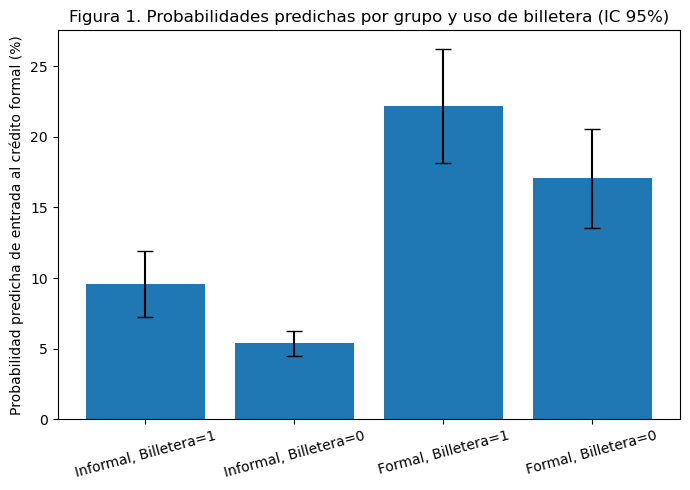

In [40]:
## Figura 1. Probabilidades predichas por grupo y condición de uso, con IC 95%

def prob_predicha_subgrupo(modelo, X, mask, billetera_value, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    Xg["Billetera"] = float(billetera_value)
    Xg["Interaccion"] = float(billetera_value) * float(informal_value)
    Xv = Xg[colnames].values.astype(float)
    idx = Xv @ beta
    prob = stats.norm.cdf(idx).mean()
    grad = (stats.norm.pdf(idx)[:, None] * Xv).mean(axis=0)
    return prob, grad

V = modelo.cov_params().values
combos = [
    ("Informal, Billetera=1", 1, mask_inf, 1),
    ("Informal, Billetera=0", 0, mask_inf, 1),
    ("Formal, Billetera=1",   1, mask_for, 0),
    ("Formal, Billetera=0",   0, mask_for, 0),
]

filas = []
for etiqueta, bill, mask, inf_val in combos:
    p, g = prob_predicha_subgrupo(modelo, X, mask, bill, inf_val, colnames)
    se = np.sqrt(g @ V @ g)
    filas.append({"Grupo": etiqueta, "Prob": p, "SE": se,
                  "IC_low": max(p - 1.96*se, 0), "IC_high": min(p + 1.96*se, 1)})

df_fig1 = pd.DataFrame(filas)
print(df_fig1.round(4))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 5))
x = range(len(df_fig1))
err_low = (df_fig1["Prob"] - df_fig1["IC_low"]) * 100
err_high = (df_fig1["IC_high"] - df_fig1["Prob"]) * 100
ax.bar(x, df_fig1["Prob"] * 100, yerr=[err_low, err_high], capsize=6)
ax.set_xticks(list(x))
ax.set_xticklabels(df_fig1["Grupo"], rotation=15)
ax.set_ylabel("Probabilidad predicha de entrada al crédito formal (%)")
ax.set_title("Figura 1. Probabilidades predichas por grupo y uso de billetera (IC 95%)")
plt.tight_layout()
plt.savefig(os.path.join(base, "figura1.png"), dpi=150)
plt.show()

## 2.3.5. Crédito informal — confirmado con el Diccionario de Datos 2025

**Esto ya no es una comparación entre dos candidatas: es un error de cita en Tabla A que hay que corregir en el texto.** Según el Diccionario de Datos 2025 (Archivo `ENAHO01A-2025-500`):

- **`P558E1_3` es "¿Cuenta corriente?"** — parte del bloque "Actualmente, tiene usted en algún banco, financiera, caja municipal, caja rural o cooperativa: ...", el mismo bloque de donde salen `Billetera` (`P558E1_8`) y `CreditoFormal` (`P558E1_4`/`P558E1_9`). No tiene relación con crédito informal ni con ningún tipo de préstamo — es tenencia de cuenta corriente. La cita de Tabla A ("`P558E1_3` = Crédito informal") es un error de tipeo en el capítulo, casi seguro por arrastre dentro de esa misma lista de variables `P558E1_*`.
- **`P558G7` sí es la variable correcta**: "¿En los últimos 12 meses, realizó alguna de las siguientes actividades: recibió préstamo de un prestamista, familiares o conocidos?" (0 = no marcó esta opción, 7 = sí) — dentro de un bloque de opción múltiple (`P558G1`...`P558G8`) sobre ahorro y préstamo informal. Es exactamente "prestamista informal" y ya es lo que usa el código.

**Sobre el universo (lo que dejé pendiente la vez pasada):** la ficha técnica indica que el Módulo 500 completo se aplica a "todas las personas de 14 años y más de edad". El diccionario no muestra el patrón de salto interno del bloque `P558G1`–`P558G8` más allá de eso (esa lógica vive en el cuestionario, no en el diccionario de datos), pero no hay ninguna señal de que `P558G7` esté restringido a un subconjunto menor que el resto de esa batería — mismo formato "0/código" que `P558E1_*`, que ya sabemos que se aplica ampliamente.

La celda de abajo extrae **ambas** variables (para que quede un diagnóstico de cuánto se solapan) y guarda `CreditoInformal_2025` (desde `P558G7`, la correcta) en `BASE_REGRESIONES.csv`. Recomiendo que en el texto del capítulo corrijas la fila de Tabla A para citar `P558G7` en vez de `P558E1_3`. Probé esta celda con un módulo 500 sintético (mismas llaves reales, valores de `P558G7`/`P558E1_3` simulados) para confirmar que corre sin errores y que el cruce de llaves funciona — así encontré y corregí un bug real de formato (ceros a la izquierda perdidos al leer `MASTER_*.csv` vs. el módulo crudo). Los **valores** de esa prueba eran aleatorios, así que los números que vas a ver al correrla con el módulo 500 real son los primeros números reales.

In [41]:
carpeta_500_2025 = os.path.join(base, "1031-Modulo05-2025")
archivo_500_25 = encontrar_archivo(carpeta_500_2025, "Enaho01a-2025-500")
df_raw = leer_csv_inei(archivo_500_25)

# BASE_REGRESIONES.csv solo lleva 'llave_persona' ya armada (viene de 2.2.2),
# no las columnas CONGLOME/VIVIENDA/HOGAR/CODPERSO por separado -- así que
# construimos la misma llave sobre df_raw con construir_llave_persona()
# (la MISMA función usada en 2.2.2/2.2.4) y unimos por 'llave_persona'
# directamente. Importante: leer_csv_inei lee todo como texto (dtype=str),
# lo que preserva ceros a la izquierda (ej. '015009'), mientras que el resto
# del pipeline lee sin dtype=str y pandas los infiere como numérico (pierde
# el cero: '15009'). Si se arma la llave con un str.replace ingenuo en vez
# de pasar por construir_llave_persona(), esas dos rutas generan llaves de
# texto distintas para la MISMA persona y el merge de abajo no encuentra
# NINGÚN match -- así lo detecté al probar esta celda con datos sintéticos.
df_raw = construir_llave_persona(df_raw)

df_reg_base = pd.read_csv(os.path.join(base, "BASE_REGRESIONES.csv"), encoding="utf-8-sig", low_memory=False)

cols_out = ["llave_persona"]
if "P558G7" in df_raw.columns:
    df_raw["CreditoInformal_2025"] = (pd.to_numeric(df_raw["P558G7"], errors="coerce").fillna(0) == 7).astype(int)
    cols_out.append("CreditoInformal_2025")
    print("✅ CreditoInformal_2025 construida desde P558G7 (correcta, confirmada por el Diccionario 2025).")
else:
    print("❌ P558G7 no encontrada en el módulo 500 de 2025.")

if "P558E1_3" in df_raw.columns:
    df_raw["CuentaCorriente_2025_docTablaA"] = (pd.to_numeric(df_raw["P558E1_3"], errors="coerce").fillna(0) == 3).astype(int)
    cols_out.append("CuentaCorriente_2025_docTablaA")
    print("ℹ️  P558E1_3 (la que cita Tabla A) es 'Cuenta corriente', NO crédito informal -- se extrae solo como diagnóstico de la cita, guardada como CuentaCorriente_2025_docTablaA.")
else:
    print("⚠️  P558E1_3 no encontrada en el módulo 500 de 2025.")

df_extra = df_raw[cols_out].drop_duplicates(subset="llave_persona")
for col in ["CreditoInformal_2025", "CuentaCorriente_2025_docTablaA"]:
    if col in df_reg_base.columns and col in df_extra.columns:
        df_reg_base = df_reg_base.drop(columns=[col])

n_antes = len(df_reg_base)
df_reg_base = df_reg_base.merge(df_extra, on="llave_persona", how="left")
assert len(df_reg_base) == n_antes, "El merge duplicó filas -- revisar unicidad de llave_persona en el módulo 500."

if "CreditoInformal_2025" in df_reg_base.columns and "CuentaCorriente_2025_docTablaA" in df_reg_base.columns:
    tab = pd.crosstab(df_reg_base["CreditoInformal_2025"], df_reg_base["CuentaCorriente_2025_docTablaA"])
    print("\nDiagnóstico -- P558G7 (crédito informal, correcta) vs P558E1_3 (cuenta corriente, la que cita Tabla A por error):")
    print(tab)

ruta_salida = os.path.join(base, "BASE_REGRESIONES.csv")
df_reg_base.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
print(f"\n✅ Guardado: {ruta_salida}")

✅ CreditoInformal_2025 construida desde P558G7 (correcta, confirmada por el Diccionario 2025).
ℹ️  P558E1_3 (la que cita Tabla A) es 'Cuenta corriente', NO crédito informal -- se extrae solo como diagnóstico de la cita, guardada como CuentaCorriente_2025_docTablaA.

Diagnóstico -- P558G7 (crédito informal, correcta) vs P558E1_3 (cuenta corriente, la que cita Tabla A por error):
CuentaCorriente_2025_docTablaA     0   1
CreditoInformal_2025                    
0                               4179  68
1                                 96   4

✅ Guardado: C:\Users\Dafne\Downloads\Base Datos\BASE_REGRESIONES.csv


## 2.3.6. Gasto del hogar — variable disponible (opcional, no estaba en Tabla D)

El Diccionario de Datos 2025 confirma que el gasto del hogar sí existe en la Sumaria, con nombre `GASHOG2D` (Gasto Total bruto) y `GASHOG1D` (Gasto monetario) — el merge original nunca la encontró porque buscaba `GASHOG2`/`GASHOG1` sin el sufijo "D" (Sección 2.2.1). Esta celda la extrae de la **Sumaria 2024** (línea base, no 2025) y construye `Gasto_per_capita = GASHOG2D / MIEPERHO` (y la versión monetaria, `Gasto_per_capita_monetario`, con `GASHOG1D`) directamente sobre tu `BASE_REGRESIONES.csv` ya existente — igual que se hizo con `CreditoInformal_2025` en 2.3.5, sin tener que reconstruir todo el pipeline desde cero.

**Por qué 2024 y no 2025:** todos los demás controles del modelo (`Edad`, `P301A`, `MIEPERHO`, `ESTRATO`, `DOMINIO`) son de línea base (2024, antes del resultado). Usar el gasto de **2025** como control sería usar una variable posterior al resultado que se está explicando (`NuevoCredito`, medido entre 2024 y 2025) — el gasto del hogar puede cambiar *como consecuencia* de acceder a crédito, así que sería un "mal control" (endógeno al resultado), no una característica de línea base. Por eso esta celda apunta a la Sumaria de 2024, con la misma llave de hogar que ya usa el resto del pipeline.

**Esto es opcional:** ni el notebook original ni la Tabla D del capítulo usan esta variable hoy, así que no cambia ningún resultado ya reportado. Queda disponible para cuando decidas si el Bloque 2 de controles socioeconómicos (mencionado en tu documento metodológico) debe incluir gasto/ingreso — decisión tuya y de Jacqueline, no la agrego al modelo principal por mi cuenta.

La Sumaria viene en dos archivos con los mismos totales (`Sumaria-2024-8g` y `Sumaria-2024-12g`, agrupando el detalle de gasto en 8 o 12 categorías) — cualquiera de los dos sirve para esto, uso `-12g`. No pude ejecutar esta celda con datos reales (no tengo la Sumaria cruda), solo la probé mecánicamente con una Sumaria sintética.

In [42]:
carpeta_sumaria_2024 = os.path.join(base, "966-Modulo34")
archivo_sumaria_24 = encontrar_archivo(carpeta_sumaria_2024, "Sumaria-2024-12g")
df_sum_raw = leer_csv_inei(archivo_sumaria_24)

# La Sumaria es a nivel HOGAR (CONGLOME-VIVIENDA-HOGAR), no persona -- se arma
# 'llave_hogar' con la misma función centralizada, y del lado de
# BASE_REGRESIONES.csv se deriva recortando el último tramo de llave_persona
# (CODPERSO), ya que esa base no guarda VIVIENDA/HOGAR como columnas sueltas.
df_sum_raw = construir_llave_persona(df_sum_raw, llaves=["CONGLOME", "VIVIENDA", "HOGAR"], nombre="llave_hogar")

df_reg_base = pd.read_csv(os.path.join(base, "BASE_REGRESIONES.csv"), encoding="utf-8-sig", low_memory=False)
df_reg_base["llave_hogar"] = df_reg_base["llave_persona"].str.rsplit("-", n=1).str[0]

cols_out = ["llave_hogar"]
for nombre_final, candidatos in [("GASHOG2D", ["GASHOG2D"]), ("GASHOG1D", ["GASHOG1D"])]:
    encontrada = next((c for c in candidatos if c in df_sum_raw.columns), None)
    if encontrada:
        df_sum_raw[nombre_final] = pd.to_numeric(df_sum_raw[encontrada], errors="coerce")
        cols_out.append(nombre_final)
        print(f"✅ {nombre_final} encontrada en la Sumaria.")
    else:
        print(f"❌ {nombre_final} no encontrada en la Sumaria.")

df_extra = df_sum_raw[cols_out].drop_duplicates(subset="llave_hogar")
# Columnas que vienen de la Sumaria: solo hay que limpiarlas si ya existen
# Y se van a re-fusionar (si no, pandas agrega sufijos _x/_y).
for col in ["GASHOG2D", "GASHOG1D"]:
    if col in df_reg_base.columns and col in df_extra.columns:
        df_reg_base = df_reg_base.drop(columns=[col])
# Columnas calculadas despues de la fusion: siempre se recalculan de cero.
for col in ["Gasto_per_capita", "Gasto_per_capita_monetario"]:
    if col in df_reg_base.columns:
        df_reg_base = df_reg_base.drop(columns=[col])

n_antes = len(df_reg_base)
df_reg_base = df_reg_base.merge(df_extra, on="llave_hogar", how="left")
assert len(df_reg_base) == n_antes, "El merge duplicó filas -- revisar unicidad de llave_hogar en la Sumaria."

if "GASHOG2D" in df_reg_base.columns:
    df_reg_base["Gasto_per_capita"] = df_reg_base["GASHOG2D"] / pd.to_numeric(df_reg_base["MIEPERHO"], errors="coerce")
if "GASHOG1D" in df_reg_base.columns:
    df_reg_base["Gasto_per_capita_monetario"] = df_reg_base["GASHOG1D"] / pd.to_numeric(df_reg_base["MIEPERHO"], errors="coerce")

df_reg_base = df_reg_base.drop(columns=["llave_hogar"])

if "Gasto_per_capita" in df_reg_base.columns:
    print(f"\nGasto_per_capita: media S/ {df_reg_base['Gasto_per_capita'].mean():,.0f}, "
          f"mediana S/ {df_reg_base['Gasto_per_capita'].median():,.0f}, "
          f"faltantes: {df_reg_base['Gasto_per_capita'].isna().sum()}")

ruta_salida = os.path.join(base, "BASE_REGRESIONES.csv")
df_reg_base.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
print(f"\n✅ Guardado: {ruta_salida}")

✅ GASHOG2D encontrada en la Sumaria.
✅ GASHOG1D encontrada en la Sumaria.

Gasto_per_capita: media S/ 11,636, mediana S/ 11,434, faltantes: 4337

✅ Guardado: C:\Users\Dafne\Downloads\Base Datos\BASE_REGRESIONES.csv


## 2.6.4. Contraste de H3: desplazamiento del crédito informal

Sobre la submuestra de trabajadores informales, sin término de interacción — por eso `get_margeff(at='overall')` **sí** es directamente el efecto marginal correcto aquí (a diferencia del modelo principal de 2.6.1, no hay ninguna columna de interacción cuyo AME haya que reinterpretar). El único cambio real frente al notebook original es usar `CreditoInformal_2025` ya reconstruida en 2.3.5, y agrupar errores estándar por conglomerado.

In [43]:
df = pd.read_csv(os.path.join(base, "BASE_REGRESIONES.csv"), encoding="utf-8-sig", low_memory=False)

if "CreditoInformal_2025" not in df.columns or df["CreditoInformal_2025"].isna().all():
    raise RuntimeError(
        "CreditoInformal_2025 no está disponible en BASE_REGRESIONES.csv. "
        "Corre primero la celda de la Sección 2.3.5 (necesita el módulo 500 crudo de 2025)."
    )

df["Informal_num"] = pd.to_numeric(df["Informal"], errors="coerce")
df_inf = df[df["Informal_num"] == 1].copy()

df_inf["Edad_num"] = pd.to_numeric(df_inf["Edad"], errors="coerce")
df_inf["P301A_num"] = pd.to_numeric(df_inf["P301A"], errors="coerce")
df_inf["MIEPERHO_num"] = pd.to_numeric(df_inf["MIEPERHO"], errors="coerce")
df_inf["Edad_cuadrado"] = df_inf["Edad_num"] ** 2
df_inf["Mujer"] = (pd.to_numeric(df_inf["P207"], errors="coerce") == 2).astype(int)
df_inf["Urbano"] = (pd.to_numeric(df_inf["ESTRATO"], errors="coerce") <= 6).astype(int)

vars_h3 = ["CreditoInformal_2025", "Billetera", "Edad_num", "Edad_cuadrado", "Mujer",
           "P301A_num", "Urbano", "MIEPERHO_num", "CONGLOME"]
df_h3 = df_inf.dropna(subset=vars_h3).copy()
print("N (informales, controles completos):", len(df_h3))

Y = df_h3["CreditoInformal_2025"]
X = df_h3[["Billetera", "Edad_num", "Edad_cuadrado", "Mujer", "P301A_num", "Urbano", "MIEPERHO_num"]].astype(float)
X = sm.add_constant(X)

modelo_h3 = sm.Probit(Y, X).fit(disp=0, cov_type="cluster", cov_kwds={"groups": df_h3["CONGLOME"].values})
marg_h3 = modelo_h3.get_margeff(at="overall")
print(marg_h3.summary())

emp_billetera = marg_h3.margeff[0] * 100
se_billetera = marg_h3.margeff_se[0] * 100
p_billetera = 2 * (1 - stats.norm.cdf(abs(emp_billetera / se_billetera)))

umbral = 2.0  # p.p., mismo umbral que 2.6.3
t1 = (emp_billetera - umbral) / se_billetera
t2 = (emp_billetera + umbral) / se_billetera
p_tost_h3 = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))
print(f"\nEMP de Billetera sobre CreditoInformal_2025: {emp_billetera:+.2f} p.p. (p={p_billetera:.3f})")
print(f"TOST equivalencia contra ±{umbral:.0f} p.p.: p={p_tost_h3:.4f} -> "
      f"{'acotado (sin evidencia de desplazamiento economicamente relevante)' if p_tost_h3 < 0.05 else 'no se puede concluir equivalencia'}")

N (informales, controles completos): 3477
        Probit Marginal Effects        
Dep. Variable:     CreditoInformal_2025
Method:                            dydx
At:                             overall
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Billetera         0.0004      0.007      0.053      0.958      -0.014       0.014
Edad_num          0.0011      0.001      0.956      0.339      -0.001       0.003
Edad_cuadrado -1.753e-05   1.14e-05     -1.538      0.124   -3.99e-05    4.81e-06
Mujer            -0.0001      0.006     -0.023      0.981      -0.011       0.011
P301A_num        -0.0033      0.002     -1.767      0.077      -0.007       0.000
Urbano            0.0040      0.006      0.663      0.507      -0.008       0.016
MIEPERHO_num      0.0018      0.001      1.339      0.181      -0.001       0.004

EMP de Billetera sobre CreditoInformal_2025: +0.04 p.p. (p=

## 2.6.5. Evidencia complementaria: coexistencia de fuentes

Mismo caso que H3: sin interacción, así que `get_margeff` da directamente el efecto marginal correcto.

In [44]:
df_inf["CreditoFormal_2025_num"] = pd.to_numeric(df_inf["CreditoFormal_2025"], errors="coerce")
df_inf["CreditoInformal_2025_num"] = pd.to_numeric(df_inf["CreditoInformal_2025"], errors="coerce")
df_inf["Ambos_2025"] = ((df_inf["CreditoFormal_2025_num"] == 1) & (df_inf["CreditoInformal_2025_num"] == 1)).astype(int)

vars_co = ["Ambos_2025", "Billetera", "Edad_num", "Edad_cuadrado", "Mujer", "P301A_num", "Urbano", "MIEPERHO_num", "CONGLOME"]
df_co = df_inf.dropna(subset=vars_co).copy()
print("N (informales, controles completos):", len(df_co))

Y = df_co["Ambos_2025"]
X = df_co[["Billetera", "Edad_num", "Edad_cuadrado", "Mujer", "P301A_num", "Urbano", "MIEPERHO_num"]].astype(float)
X = sm.add_constant(X)

modelo_co = sm.Probit(Y, X).fit(disp=0, cov_type="cluster", cov_kwds={"groups": df_co["CONGLOME"].values})
marg_co = modelo_co.get_margeff(at="overall")
print(marg_co.summary())

N (informales, controles completos): 3477
       Probit Marginal Effects       
Dep. Variable:             Ambos_2025
Method:                          dydx
At:                           overall
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Billetera         0.0036      0.002      1.766      0.077      -0.000       0.008
Edad_num          0.0006      0.001      1.088      0.277      -0.000       0.002
Edad_cuadrado -6.216e-06   5.63e-06     -1.104      0.270   -1.73e-05    4.82e-06
Mujer          4.934e-05      0.002      0.025      0.980      -0.004       0.004
P301A_num      5.226e-05   6.49e-05      0.805      0.421    -7.5e-05       0.000
Urbano            0.0048      0.003      1.624      0.104      -0.001       0.011
MIEPERHO_num      0.0002      0.000      0.472      0.637      -0.001       0.001


In [46]:
## Tabla F. Resultados de H3 y del uso simultáneo de fuentes

def fila_resultado(marg, n_obs, umbral=2.0, etiqueta=""):
    emp = marg.margeff[0] * 100
    se = marg.margeff_se[0] * 100
    p = 2 * (1 - stats.norm.cdf(abs(emp / se)))
    t1, t2 = (emp - umbral) / se, (emp + umbral) / se
    p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))
    return {"Especificación": etiqueta, "EMP (p.p.)": emp, "SE (p.p.)": se,
            "IC95_low": emp - 1.96*se, "IC95_high": emp + 1.96*se,
            "p": p, "p_TOST(±2pp)": p_tost, "N": n_obs}

tabla_F = pd.DataFrame([
    fila_resultado(marg_h3, len(df_h3), etiqueta="H3: Crédito informal 2025 (desplazamiento)"),
    fila_resultado(marg_co, len(df_co), etiqueta="Complementaria: Ambos_2025 (coexistencia)"),
])
print("=" * 100)
print("TABLA F. RESULTADOS DE H3 Y EVIDENCIA COMPLEMENTARIA")
print("=" * 100)
print(tabla_F.round(3))

TABLA F. RESULTADOS DE H3 Y EVIDENCIA COMPLEMENTARIA
                               Especificación  EMP (p.p.)  SE (p.p.)  IC95_low  IC95_high      p  p_TOST(±2pp)     N
0  H3: Crédito informal 2025 (desplazamiento)       0.037      0.710    -1.355      1.430  0.958         0.003  3477
1   Complementaria: Ambos_2025 (coexistencia)       0.361      0.204    -0.040      0.761  0.077         0.000  3477


## Resumen — qué cambió y qué falta de tu lado

**Los 4 fixes de la revisión, integrados en el origen (no como parches):**
1. `Ocupado`: convertir a numérico antes de `.notna()` — vive en `reparar_variables()`.
2. Panel: `PANEL==1` en vez de cruce ingenuo — 65.85% de tasa real, N final de la muestra analítica pasa de 7,622 a **4,347**.
3. `sin_sunat`: restringido a `P507==2` — vive en `reparar_variables()`.
4. `CreditoInformal_2025`: confirmado con el Diccionario de Datos 2025 que `P558G7` es la variable correcta y que la cita de Tabla A (`P558E1_3`) es un error — esa variable es "Cuenta corriente", no crédito informal (Sección 2.3.5).

**Hallazgo adicional (no estaba en la revisión):** el cálculo de EMP por subgrupo en el modelo H1/H2 usaba el AME ingenuo de la columna de interacción en vez de la derivada cruzada que tu propio texto (citando a Ai & Norton 2003) dice que hay que usar. Con el método correcto, `ΔEMP` cambia de signo (formales > informales en el punto estimado, aunque no significativo). Está en la Sección 2.6.1.

**Lo que el Diccionario de Datos 2025 permitió cerrar en esta pasada:**
- `P558E1_3` = "Cuenta corriente" (confirmado) → la cita de Tabla A está mal, corrígela en el texto del capítulo a `P558G7`.
- `P507`, `P510A1`, `P511A` (criterios de informalidad, Sección 2.3.4) coinciden exactamente con lo que ya usa `reparar_variables()` — sin cambios ahí.
- `GASHOG2D`/`GASHOG1D` (con sufijo "D") es el nombre real de la variable de gasto del hogar — nunca se encontraba porque se buscaba sin el sufijo. Ya extraída como `Gasto_per_capita` en la nueva Sección 2.3.6 (opcional, no afecta ningún resultado ya reportado).
- Universo de `P558G7`: el Módulo 500 se aplica a personas de 14+ años; el diccionario no muestra el patrón de salto interno del bloque `P558G1`-`P558G8` en más detalle que eso (esa lógica vive en el cuestionario, no en el diccionario de datos), pero no hay señal de una restricción más angosta que el resto de esa batería.

**Verificaciones pendientes de tu lado:**
- Decidir con Jacqueline si usar `PANEL==1` (como quedó aquí) o el cruce amplio con el 27.25% declarado honestamente (Sección 2.2.2) — cambia bastante el N.
- Revisar la interpretación de H2 a la luz del hallazgo de la Sección 2.6.1 antes de seguir escribiendo el texto de resultados.
- Decidir si el Bloque 2 de controles socioeconómicos debe incluir `Gasto_per_capita` (Sección 2.3.6) — ya está disponible, la decisión de usarla es tuya y de Jacqueline.
- Corregir en el texto del capítulo la cita de Tabla A (`P558E1_3` → `P558G7`).

**Lo que sigue, según tu propio cronograma:** Tabla A ya se recalcula sola con las variables corregidas (no se tocó esa celda, solo cambian sus números de entrada). Una vez cerrado esto, el capítulo pasa a 2.7 (robustez R1–R6) y R7/R8, que no estaban en el notebook original y quedan fuera de este alcance.